# ReturnShield: Returns Risk Prediction System

This project builds an end-to-end return-risk prediction pipeline using retail order, return, and shipping data. The goal is to identify order lines with higher return risk using Python-based feature engineering, machine learning, and SQLite database export for business analysis.

The project focuses on:
- merging multiple retail datasets
- creating customer, product, shipping, and profitability features
- training a return-risk model
- generating risk scores and recommended actions
- exporting final tables to SQLite for SQL analysis

## 1. Import Libraries

In [3]:
# Import libraries for data handling.
import pandas as pd
import numpy as np

# Import libraries for file paths and SQL.
from pathlib import Path
import sqlite3

# Import libraries for visualisation.
import matplotlib.pyplot as plt

# Import libraries for machine learning.
from sklearn.model_selection import train_test_split

# Import libraries for model comparison.
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)

## 2. Set Project Paths

In [5]:
# Set project root directory.
BASE_DIR = Path.cwd().parent

# Set folder paths.
DATA_DIR = BASE_DIR / "data"
SQL_DIR = BASE_DIR / "sql"
OUTPUT_DIR = BASE_DIR / "outputs"

# Create folders if they do not exist.
DATA_DIR.mkdir(exist_ok=True)
SQL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

#Check the folder paths
print("Project folder:", BASE_DIR)
print("Data folder:", DATA_DIR)
print("SQL folder:", SQL_DIR)
print("Output folder:", OUTPUT_DIR)

Project folder: C:\Users\sathw\ReturnShield
Data folder: C:\Users\sathw\ReturnShield\data
SQL folder: C:\Users\sathw\ReturnShield\sql
Output folder: C:\Users\sathw\ReturnShield\outputs


## 3. Load Raw Datasets

In [7]:
# Load orders, returns, and shipping cost datasets.
orders = pd.read_csv(DATA_DIR / "Orders.csv", encoding="latin1")
returns = pd.read_csv(DATA_DIR / "Return.csv", encoding="latin1")
shipping = pd.read_csv(DATA_DIR / "Shipping Cost.csv", encoding="latin1")

In [8]:
# Display dataset shapes.
print("Orders shape:", orders.shape)
print("Returns shape:", returns.shape)
print("Shipping shape:", shipping.shape)

Orders shape: (9994, 24)
Returns shape: (296, 2)
Shipping shape: (49, 2)


## 4. Clean Column Names

In [10]:
# Clean column names for all datasets.
def clean_column_names(data):
    data = data.copy()
    data.columns = (
        data.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
        .str.replace("/", "_", regex=False)
    )
    return data

orders = clean_column_names(orders)
returns = clean_column_names(returns)
shipping = clean_column_names(shipping)

# Display cleaned column names.
print("Orders columns:", orders.columns.tolist())
print("Returns columns:", returns.columns.tolist())
print("Shipping columns:", shipping.columns.tolist())

Orders columns: ['row_id', 'order_id', 'order_date', 'ship_date', 'delivery_duration', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'discount_value', 'profit', 'cogs']
Returns columns: ['returned', 'order_id']
Shipping columns: ['state', 'shipping_cost_per_unit']


## 5. Merge Datasets

In [12]:
# Merge orders with returns using order_id.
df = orders.merge(returns, on="order_id", how="left")

# Merge shipping cost using state.
df = df.merge(shipping, on="state", how="left")

# Check merged dataset size and preview.
print("Merged dataset shape:", df.shape)
df.head()


Merged dataset shape: (9994, 26)


,row_id,order_id,order_date,ship_date,delivery_duration,ship_mode,customer_id,customer_name,segment,country,...,sub_category,product_name,sales,quantity,discount,discount_value,profit,cogs,returned,shipping_cost_per_unit
0,1,CA-2016-152156,42682,42685,3,Second Class,CG-12520,Claire Gute,Consumer,United States,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,0.000000,41.9136,-220.046400,NaN,8
1,2,CA-2016-152156,42682,42685,3,Second Class,CG-12520,Claire Gute,Consumer,United States,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,0.000000,219.5820,-512.358000,NaN,8
2,3,CA-2016-138688,42533,42537,4,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,0.000000,6.8714,-7.748600,NaN,7
3,4,US-2015-108966,42288,42295,7,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-430.909875,-383.0310,-909.698625,NaN,6
4,5,US-2015-108966,42288,42295,7,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,-4.473600,2.5164,-15.378000,NaN,6


## 6. Validate Merge Quality

In [14]:
# Validate merge quality.
print("Original orders rows:", orders.shape[0])
print("Merged dataset rows:", df.shape[0])
print("Row count matched:", orders.shape[0] == df.shape[0])
print("Duplicate row_id count:", df["row_id"].duplicated().sum())

Original orders rows: 9994
Merged dataset rows: 9994
Row count matched: True
Duplicate row_id count: 0


In [15]:
# Check missing values in merged columns.
df[["returned", "shipping_cost_per_unit"]].isnull().sum()

returned                  9194
shipping_cost_per_unit       0
dtype: int64

## 7. Create Return Target

In [17]:
# Create binary return target.
df["is_returned"] = df["returned"].fillna("No").str.lower().apply(
    lambda value: 1 if value == "yes" else 0
)

df["is_returned"].value_counts()

is_returned
0    9194
1     800
Name: count, dtype: int64

Each row represents an order line rather than a full customer order. Therefore, the model predicts return risk at the order-line level using order, product, customer, shipping, and profitability features.

In [19]:
# Check return rate percentage.
(df["is_returned"].value_counts(normalize=True) * 100).round(2)

is_returned
0    92.0
1     8.0
Name: proportion, dtype: float64

## 8. Prepare Dates and Initial Business Features

In [21]:
# Convert Excel serial dates into readable dates.
df["order_date"] = pd.to_datetime(df["order_date"], origin="1899-12-30", unit="D", errors="coerce")
df["ship_date"] = pd.to_datetime(df["ship_date"], origin="1899-12-30", unit="D", errors="coerce")

In [22]:
# Create estimated shipping cost using quantity and shipping cost per unit.
df["estimated_shipping_cost"] = df["quantity"] * df["shipping_cost_per_unit"]

In [23]:
# Preview important columns for return-risk analysis.
df[
    [
        "order_id",
        "customer_id",
        "product_id",
        "category",
        "sub_category",
        "state",
        "delivery_duration",
        "sales",
        "quantity",
        "shipping_cost_per_unit",
        "estimated_shipping_cost",
        "is_returned"
    ]
].head()

,order_id,customer_id,product_id,category,sub_category,state,delivery_duration,sales,quantity,shipping_cost_per_unit,estimated_shipping_cost,is_returned
0,CA-2016-152156,CG-12520,FUR-BO-10001798,Furniture,Bookcases,Kentucky,3,261.9600,2,8,16,0
1,CA-2016-152156,CG-12520,FUR-CH-10000454,Furniture,Chairs,Kentucky,3,731.9400,3,8,24,0
2,CA-2016-138688,DV-13045,OFF-LA-10000240,Office Supplies,Labels,California,4,14.6200,2,7,14,0
3,US-2015-108966,SO-20335,FUR-TA-10000577,Furniture,Tables,Florida,7,957.5775,5,6,30,0
4,US-2015-108966,SO-20335,OFF-ST-10000760,Office Supplies,Storage,Florida,7,22.3680,2,6,12,0


## 9. Save Cleaned Merged Dataset

In [25]:
# Save merged dataset for future analysis.
cleaned_file_path = OUTPUT_DIR / "returnshield_merged_data.csv"

df.to_csv(cleaned_file_path, index=False)

print("Merged dataset saved successfully:", cleaned_file_path)

Merged dataset saved successfully: C:\Users\sathw\ReturnShield\outputs\returnshield_merged_data.csv


## 10. Feature Engineering

In [27]:
# Create shipping cost ratio.
df["shipping_cost_ratio"] = np.where(
    df["sales"] > 0,
    df["estimated_shipping_cost"] / df["sales"],
    0
)

In [28]:
# Create delivery delay flag.
df["is_delayed"] = np.where(df["delivery_duration"] > 5, 1, 0)

In [29]:
# Create customer purchase frequency.
df["customer_order_count"] = df.groupby("customer_id")["order_id"].transform("nunique")

In [30]:
# Create customer average sales value.
df["customer_avg_sales"] = df.groupby("customer_id")["sales"].transform("mean")

In [31]:
# Create order month feature.
df["order_month"] = df["order_date"].dt.month

In [32]:
# Create profit margin feature.
df["profit_margin"] = np.where(
    df["sales"] > 0,
    df["profit"] / df["sales"],
    0
)

In [33]:
# Create loss order flag.
df["is_loss_order"] = np.where(df["profit"] < 0, 1, 0)

In [34]:
# Remove infinite values created during feature engineering.
df = df.replace([np.inf, -np.inf], np.nan)

In [35]:
# Preview engineered features.
df[
    [
        "order_id",
        "customer_id",
        "product_id",
        "category",
        "sales",
        "quantity",
        "delivery_duration",
        "estimated_shipping_cost",
        "shipping_cost_ratio",
        "is_delayed",
        "customer_order_count",
        "customer_avg_sales",
        "profit_margin",
        "is_loss_order",
        "is_returned"
    ]
].head()

,order_id,customer_id,product_id,category,sales,quantity,delivery_duration,estimated_shipping_cost,shipping_cost_ratio,is_delayed,customer_order_count,customer_avg_sales,profit_margin,is_loss_order,is_returned
0,CA-2016-152156,CG-12520,FUR-BO-10001798,Furniture,261.9600,2,3,16,0.061078,0,3,229.756000,0.1600,0,0
1,CA-2016-152156,CG-12520,FUR-CH-10000454,Furniture,731.9400,3,3,24,0.032790,0,3,229.756000,0.3000,0,0
2,CA-2016-138688,DV-13045,OFF-LA-10000240,Office Supplies,14.6200,2,4,14,0.957592,0,5,124.387000,0.4700,0,0
3,US-2015-108966,SO-20335,FUR-TA-10000577,Furniture,957.5775,5,7,30,0.031329,1,6,173.505033,-0.4000,1,0
4,US-2015-108966,SO-20335,OFF-ST-10000760,Office Supplies,22.3680,2,7,12,0.536481,1,6,173.505033,0.1125,0,0


## 11. Prepare Data for Machine Learning

In [37]:
# Select identifier columns for final risk output.
id_columns = [
    "row_id",
    "order_id",
    "customer_id",
    "customer_name",
    "product_id",
    "product_name",
    "category",
    "sub_category",
    "state",
    "segment",
    "ship_mode"
]

In [38]:
# Select base features for return-risk prediction.
base_features = [
    "sales",
    "quantity",
    "discount",
    "profit",
    "profit_margin",
    "is_loss_order",
    "delivery_duration",
    "shipping_cost_per_unit",
    "estimated_shipping_cost",
    "shipping_cost_ratio",
    "is_delayed",
    "customer_order_count",
    "customer_avg_sales",
    "order_month"
]

In [39]:
# Keep only columns available in the dataset.
id_columns = [col for col in id_columns if col in df.columns]
base_features = [col for col in base_features if col in df.columns]

In [40]:
# Create modelling dataset.
model_columns = list(dict.fromkeys(id_columns + base_features + ["is_returned"]))

model_df = df[model_columns].dropna().copy()

print("Model dataset shape:", model_df.shape)

Model dataset shape: (9994, 26)


In [41]:
# Check return target distribution.
model_df["is_returned"].value_counts(normalize=True).round(3)

is_returned
0    0.92
1    0.08
Name: proportion, dtype: float64

## 12. Train-Test Split

In [43]:
# Split data into training and testing sets.
train_df, test_df = train_test_split(
    model_df,
    test_size=0.2,
    random_state=42,
    stratify=model_df["is_returned"]
)

# Create clean copies for feature creation.
train_df = train_df.copy()
test_df = test_df.copy()

print("Training data:", train_df.shape)
print("Testing data:", test_df.shape)

Training data: (7995, 26)
Testing data: (1999, 26)


## 13. Product and Category Return-Risk Features

In [45]:
# Create return-rate feature using training data only.
def add_return_rate_feature(train_data, test_data, group_column, feature_name):
    global_return_rate = train_data["is_returned"].mean()
    return_rate_map = train_data.groupby(group_column)["is_returned"].mean()

    train_data[feature_name] = train_data[group_column].map(return_rate_map).fillna(global_return_rate)
    test_data[feature_name] = test_data[group_column].map(return_rate_map).fillna(global_return_rate)

    return train_data, test_data

In [46]:
# Create product-level return-rate feature.
train_df, test_df = add_return_rate_feature(
    train_df,
    test_df,
    "product_id",
    "product_return_rate"
)

In [47]:
# Create category-level return-rate feature.
train_df, test_df = add_return_rate_feature(
    train_df,
    test_df,
    "category",
    "category_return_rate"
)

In [48]:
# Create sub-category-level return-rate feature.
train_df, test_df = add_return_rate_feature(
    train_df,
    test_df,
    "sub_category",
    "sub_category_return_rate"
)

In [49]:
# Create final feature list.
risk_features = [
    "product_return_rate",
    "category_return_rate",
    "sub_category_return_rate"
]

final_features = base_features + risk_features

print("Final features used:")
final_features

Final features used:


['sales',
 'quantity',
 'discount',
 'profit',
 'profit_margin',
 'is_loss_order',
 'delivery_duration',
 'shipping_cost_per_unit',
 'estimated_shipping_cost',
 'shipping_cost_ratio',
 'is_delayed',
 'customer_order_count',
 'customer_avg_sales',
 'order_month',
 'product_return_rate',
 'category_return_rate',
 'sub_category_return_rate']

## 14. Compare Return Risk models

In [51]:
# Create final training and testing inputs.
X_train = train_df[final_features]
y_train = train_df["is_returned"]

X_test = test_df[final_features]
y_test = test_df["is_returned"]

In [52]:
# Create sample weights for models that do not directly support class_weight.
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

In [53]:
# Define models for comparison.
models = {
    "Logistic Regression": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            solver="liblinear",
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=3,
        random_state=42,
        class_weight="balanced"
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=3,
        random_state=42,
        class_weight="balanced"
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [54]:
# Train and evaluate each model.
model_results = []
trained_models = {}

for model_name, model in models.items():
    
    if model_name == "Gradient Boosting":
        model.fit(X_train, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    trained_models[model_name] = model
    
    model_results.append({
        "model": model_name,
        "accuracy": round(accuracy_score(y_test, y_pred), 3),
        "precision_returned": round(precision_score(y_test, y_pred, zero_division=0), 3),
        "recall_returned": round(recall_score(y_test, y_pred, zero_division=0), 3),
        "f1_returned": round(f1_score(y_test, y_pred, zero_division=0), 3),
        "roc_auc": round(roc_auc_score(y_test, y_proba), 3),
        "average_precision": round(average_precision_score(y_test, y_proba), 3)
    })

model_comparison = (
    pd.DataFrame(model_results)
    .sort_values(by="roc_auc", ascending=False)
    .reset_index(drop=True)
)

model_comparison.index = model_comparison.index + 1

model_comparison

,model,accuracy,precision_returned,recall_returned,f1_returned,roc_auc,average_precision
1,Gradient Boosting,0.693,0.081,0.275,0.126,0.582,0.097
2,Random Forest,0.723,0.085,0.250,0.126,0.578,0.096
3,Extra Trees,0.710,0.085,0.269,0.129,0.563,0.092
4,Logistic Regression,0.715,0.077,0.231,0.115,0.504,0.079


Gradient Boosting achieved the best ROC-AUC score among the compared models. However, the returned class remains difficult to predict because returned order lines represent only around 8% of the dataset. Therefore, this project focuses on building an end-to-end return-risk pipeline and generating decision-ready risk scores, rather than claiming production-level prediction accuracy.

## 15. Select the best model

In [57]:
# Select the best model based on ROC-AUC score.
best_model_name = model_comparison.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("Best model selected:", best_model_name)

Best model selected: Gradient Boosting


In [58]:
# Generate final predictions using the best model.
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)
average_precision = average_precision_score(y_test, y_proba)

print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("ROC-AUC Score:", round(roc_auc, 3))
print("Average Precision Score:", round(average_precision, 3))

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.73      0.81      1839
           1       0.08      0.28      0.13       160

    accuracy                           0.69      1999
   macro avg       0.50      0.50      0.47      1999
weighted avg       0.85      0.69      0.76      1999

ROC-AUC Score: 0.582
Average Precision Score: 0.097


In [59]:
# Create confusion matrix for the best model.
confusion_df = pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=["Actual Not Returned", "Actual Returned"],
    columns=["Predicted Not Returned", "Predicted Returned"]
)

confusion_df

,Predicted Not Returned,Predicted Returned
Actual Not Returned,1342,497
Actual Returned,116,44


## 16. Feature Importance

In [61]:
# Extract feature importance from the selected model.
def get_feature_importance(selected_model, feature_names):
    model_object = selected_model
    
    if hasattr(selected_model, "named_steps"):
        model_object = selected_model.named_steps["model"]
    
    if hasattr(model_object, "feature_importances_"):
        importance_values = model_object.feature_importances_
    elif hasattr(model_object, "coef_"):
        importance_values = np.abs(model_object.coef_[0])
    else:
        importance_values = np.full(len(feature_names), np.nan)
    
    importance_table = pd.DataFrame({
        "feature": feature_names,
        "importance": importance_values
    }).sort_values(by="importance", ascending=False)
    
    return importance_table

In [62]:
# Create feature importance table.
feature_importance = get_feature_importance(best_model, final_features)

feature_importance

,feature,importance
14,product_return_rate,0.891898
7,shipping_cost_per_unit,0.031176
12,customer_avg_sales,0.025112
13,order_month,0.010774
11,customer_order_count,0.009943
0,sales,0.008670
3,profit,0.006091
8,estimated_shipping_cost,0.004634
6,delivery_duration,0.004194
4,profit_margin,0.003015


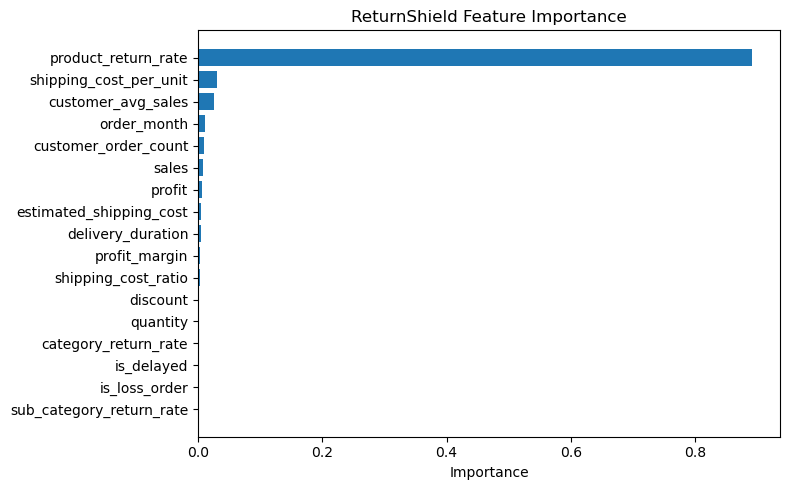

In [63]:
# Plot and save feature importance.
if feature_importance["importance"].notna().all():
    plt.figure(figsize=(8, 5))
    plt.barh(feature_importance["feature"], feature_importance["importance"])
    plt.gca().invert_yaxis()
    plt.title("ReturnShield Feature Importance")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "returnshield_feature_importance_plot.png", dpi=300, bbox_inches="tight")
    plt.show()

## 17. Generate Return Risk Scores

In [65]:
# Select columns for return risk output.
risk_output_columns = id_columns + [
    "sales",
    "quantity",
    "delivery_duration",
    "estimated_shipping_cost",
    "is_delayed",
    "is_returned"
]

risk_output_columns = [col for col in risk_output_columns if col in test_df.columns]

In [66]:
# Create risk output dataset.
risk_output = test_df[risk_output_columns].copy()

risk_output["return_risk_score"] = y_proba

In [67]:
# Create return risk levels.
risk_output["risk_level"] = pd.cut(
    risk_output["return_risk_score"],
    bins=[-0.01, 0.30, 0.60, 1.00],
    labels=["Low", "Medium", "High"]
)

In [68]:
# Add recommended business action.
risk_output["recommended_action"] = np.where(
    risk_output["risk_level"] == "High",
    "Review before fulfilment",
    np.where(
        risk_output["risk_level"] == "Medium",
        "Monitor order",
        "Standard processing"
    )
)

In [69]:
# Convert risk level to text for clean export.
risk_output["risk_level"] = risk_output["risk_level"].astype(str)

In [142]:
# Preview highest-risk order lines.
risk_sample = (
    risk_output[
        [
            "order_id",
            "customer_id",
            "category",
            "sub_category",
            "state",
            "sales",
            "delivery_duration",
            "is_returned",
            "return_risk_score",
            "risk_level",
            "recommended_action"
        ]
    ]
    .sort_values("return_risk_score", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

risk_sample.index = risk_sample.index + 1

risk_sample

,order_id,customer_id,category,sub_category,state,sales,delivery_duration,is_returned,return_risk_score,risk_level,recommended_action
1,CA-2015-134082,JK-15640,Office Supplies,Binders,California,110.528,6,0,0.961247,High,Review before fulfilment
2,CA-2015-157959,RW-19540,Furniture,Furnishings,California,136.920,1,0,0.953065,High,Review before fulfilment
3,US-2017-164056,FM-14215,Furniture,Tables,Ohio,1048.350,5,0,0.949812,High,Review before fulfilment
4,CA-2014-150203,JB-15925,Office Supplies,Appliances,California,250.260,2,0,0.948570,High,Review before fulfilment
5,CA-2014-107181,DB-13270,Office Supplies,Binders,California,82.896,4,0,0.947242,High,Review before fulfilment
6,CA-2017-134880,TW-21025,Office Supplies,Paper,Arizona,44.784,5,0,0.943118,High,Review before fulfilment
7,CA-2016-140382,RD-19900,Office Supplies,Storage,California,93.680,2,0,0.937967,High,Review before fulfilment
8,CA-2014-123925,RF-19840,Office Supplies,Art,Georgia,40.050,2,0,0.937958,High,Review before fulfilment
9,CA-2017-163405,BN-11515,Office Supplies,Art,California,5.880,4,0,0.937700,High,Review before fulfilment
10,CA-2017-117667,MS-17980,Furniture,Furnishings,Pennsylvania,54.768,5,0,0.937126,High,Review before fulfilment


This preview shows the highest predicted return-risk order lines from the test set. Some high-risk predictions may not result in actual returns, which reflects the model’s moderate performance and the need for further feature improvement.

## 18. Create Model Metrics Summary

In [72]:
# Create model metrics summary.
model_metrics = pd.DataFrame({
    "metric": [
        "best_model",
        "total_model_rows",
        "training_rows",
        "testing_rows",
        "return_rate",
        "roc_auc_score",
        "average_precision_score"
    ],
    "value": [
        best_model_name,
        model_df.shape[0],
        train_df.shape[0],
        test_df.shape[0],
        round(model_df["is_returned"].mean(), 4),
        round(roc_auc, 3),
        round(average_precision, 3)
    ]
})

model_metrics

,metric,value
0,best_model,Gradient Boosting
1,total_model_rows,9994
2,training_rows,7995
3,testing_rows,1999
4,return_rate,0.08
5,roc_auc_score,0.582
6,average_precision_score,0.097


## 19. Save Project Outputs

In [74]:
# Save final cleaned dataset.
df.to_csv(OUTPUT_DIR / "returnshield_cleaned_dataset.csv", index=False)

In [75]:
# Save return risk scores.
risk_output.to_csv(OUTPUT_DIR / "returnshield_risk_scores.csv", index=False)

In [76]:
# Save model comparison table.
model_comparison.to_csv(OUTPUT_DIR / "returnshield_model_comparison.csv", index=False)

In [77]:
# Save feature importance table.
feature_importance.to_csv(OUTPUT_DIR / "returnshield_feature_importance.csv", index=False)

In [78]:
# Save confusion matrix.
confusion_df.to_csv(OUTPUT_DIR / "returnshield_confusion_matrix.csv")

In [79]:
# Save model metrics summary.
model_metrics.to_csv(OUTPUT_DIR / "returnshield_model_metrics.csv", index=False)

print("All project output files saved successfully.")

All project output files saved successfully.


## 20. Export Tables to SQLite Database

In [81]:
# Create SQLite database path inside the sql folder.
db_path = SQL_DIR / "returnshield.db"

In [82]:
# Export project outputs to SQLite database.
with sqlite3.connect(db_path) as conn:
    df.to_sql("orders_cleaned", conn, if_exists="replace", index=False)
    risk_output.to_sql("return_risk_scores", conn, if_exists="replace", index=False)
    model_comparison.to_sql("model_comparison", conn, if_exists="replace", index=False)
    feature_importance.to_sql("feature_importance", conn, if_exists="replace", index=False)
    confusion_df.to_sql("confusion_matrix", conn, if_exists="replace", index=True)
    model_metrics.to_sql("model_metrics", conn, if_exists="replace", index=False)

print("SQLite database exported successfully:", db_path)

SQLite database exported successfully: C:\Users\sathw\ReturnShield\sql\returnshield.db
